In [1]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense

In [2]:
path_of_dir=os.listdir('../brain tumor/Brain Tumor Data Set/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [3]:
Y=[]
X=[]
for i in classes_in_dir:
    path='../brain tumor/Brain Tumor Data Set/'+i
    for j in os.listdir(path):
        pic=cv2.imread(path+'/'+j,1)
        pic=cv2.resize(pic,(200,200))
        X.append(pic)
        Y.append(classes_in_dir[i])


In [4]:
x=np.array(X,dtype=np.uint8)
y=np.array(Y,dtype=np.uint8)
pd.Series(y).value_counts()

1    2513
0    2087
Name: count, dtype: int64

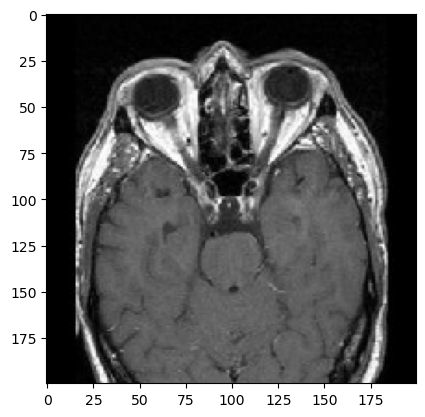

In [5]:
plt.imshow(x[1])


In [6]:
x.shape

(4600, 200, 200, 3)

In [7]:
x_3D=x.reshape(-1,200,200)
x_3D.shape

(13800, 200, 200)

In [8]:
x_3D.ndim

3

In [9]:
x_2D=x.reshape(len(x),-1)

In [10]:
x_2D.ndim

2

In [11]:
x_2D.shape

(4600, 120000)

In [12]:
x_2D.ndim

2

In [13]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x,y,random_state=10,test_size=0.20)


In [14]:
x_train3D.shape

(3680, 200, 200, 3)

#CNN MODEL

In [15]:
cnn=tf.keras.models.Sequential([ keras.layers.Input(shape=(200,200,3)), 
Conv2D(filters=32, kernel_size=(5, 5), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1,activation='sigmoid') # output layer

])
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 196, 196, 32)      2432      
                                                                 
 batch_normalization (BatchN  (None, 196, 196, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 98, 98, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 96, 96, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 96, 96, 64)       256       
 hNormalization)                                                 
                                                        

In [16]:
cnn.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
#train
cnn.fit(x_train3D,y_train3D, epochs=5, batch_size=32 ,validation_data=(x_test3D,y_test3D))

Epoch 1/5
115/115 [==============================] - 72s 618ms/step - loss: 2.2418 - accuracy: 0.8035 - val_loss: 0.8743 - val_accuracy: 0.8739
Epoch 2/5
115/115 [==============================] - 73s 636ms/step - loss: 0.6896 - accuracy: 0.9242 - val_loss: 0.4987 - val_accuracy: 0.9109
Epoch 3/5
115/115 [==============================] - 71s 619ms/step - loss: 0.2855 - accuracy: 0.9614 - val_loss: 2.6874 - val_accuracy: 0.7413
Epoch 4/5
115/115 [==============================] - 71s 616ms/step - loss: 0.2216 - accuracy: 0.9688 - val_loss: 0.3597 - val_accuracy: 0.9467
Epoch 5/5
115/115 [==============================] - 70s 613ms/step - loss: 0.1098 - accuracy: 0.9826 - val_loss: 0.7093 - val_accuracy: 0.9424


In [18]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

29/29 - 4s - loss: 0.7093 - accuracy: 0.9424 - 4s/epoch - 142ms/step


In [19]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

29/29 [==============================] - 5s 151ms/step


In [20]:
accuracy_score(y_test3D,pred1)

0.9423913043478261

In [21]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(conf_mat)
print(classification_report(y_test3D,pred1))


[[390  26]
 [ 27 477]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       416
           1       0.95      0.95      0.95       504

    accuracy                           0.94       920
   macro avg       0.94      0.94      0.94       920
weighted avg       0.94      0.94      0.94       920



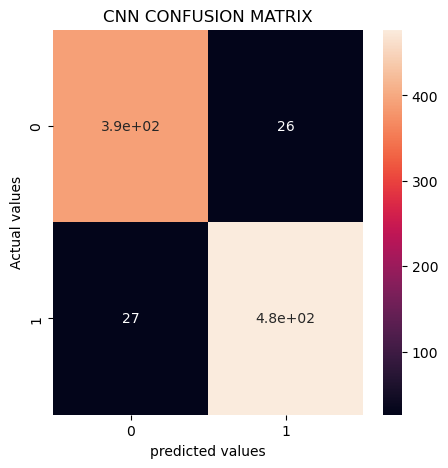

In [22]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [23]:
x_2D.shape

(4600, 120000)

In [24]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_2D,y,random_state=10,test_size=0.20)

In [25]:
x_train2D=x_train2D/255
x_test2D=x_test2D/255

In [26]:
x_train2D.shape

(3680, 120000)

In [27]:

rf=RandomForestClassifier()
rf.fit(x_train2D,y_train2D)

RandomForestClassifier()

In [28]:
pred2=rf.predict(x_test2D)

In [29]:
accuracy_score(y_test2D,pred2)

0.967391304347826

In [30]:

conf_mat2=confusion_matrix(y_test2D,pred2)


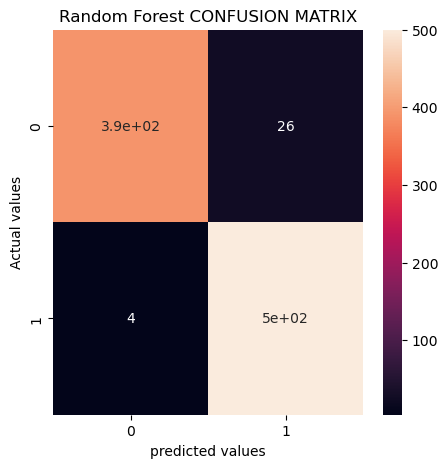

In [31]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [32]:
# SVM

svm= SVC(kernel='linear',random_state=32)
svm.fit(x_train2D,y_train2D)

SVC(kernel='linear', random_state=32)

In [33]:
pred3=svm.predict(x_test2D)

In [34]:
accuracy_score(y_test2D,pred3)

0.9532608695652174

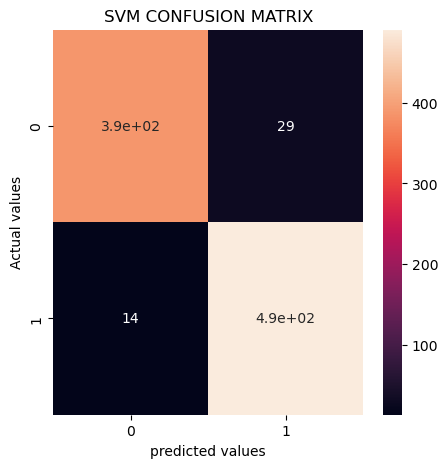

In [35]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [36]:
knn=KNeighborsClassifier()
knn.fit(x_train2D,y_train2D)

KNeighborsClassifier()

In [37]:
pred4=knn.predict(x_test2D)

In [38]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.883695652173913

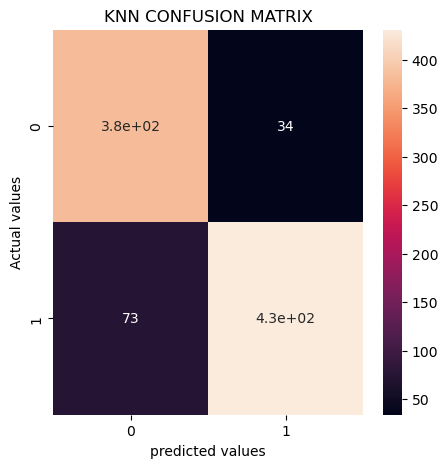

In [39]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [40]:
LR = LogisticRegression(max_iter=1000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

LogisticRegression(max_iter=1000)

In [41]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.9597826086956521

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       416
           1       0.95      0.97      0.96       504

    accuracy                           0.96       920
   macro avg       0.96      0.96      0.96       920
weighted avg       0.96      0.96      0.96       920



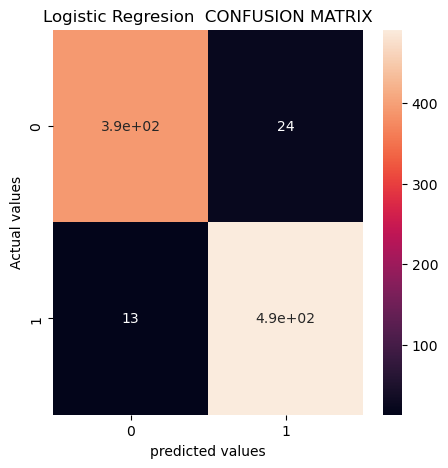

In [42]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

Text(0.5, 0, '1')

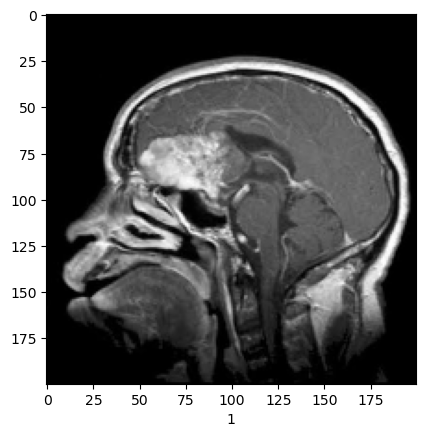

In [43]:
w=plt.imshow(x_test3D[50] ,cmap='gray')
plt.xlabel(y_test3D[50])

In [44]:
f=np.where(y_test3D != pred1)[0]

In [45]:
print(f)

[ 13  50  55  67  74  94 116 121 133 141 160 162 192 203 211 218 240 278
 325 326 388 415 418 448 488 494 498 515 533 541 543 558 565 574 661 684
 699 717 728 752 774 779 804 816 827 829 855 859 861 864 876 906 913]


In [46]:
print("Y_test =",y_test2D[103])

Y_test = 1


In [47]:
print("CNN =",pred1[103])

CNN = 1


In [48]:
print("RF =",pred2[103])

RF = 1


In [49]:
print("SVM =",pred3[103])

SVM = 1


In [50]:
print("KNN =",pred4[103])

KNN = 1


In [51]:
print("LR =",pred5[103])

LR = 1


# ALL PREDICTED VALUES

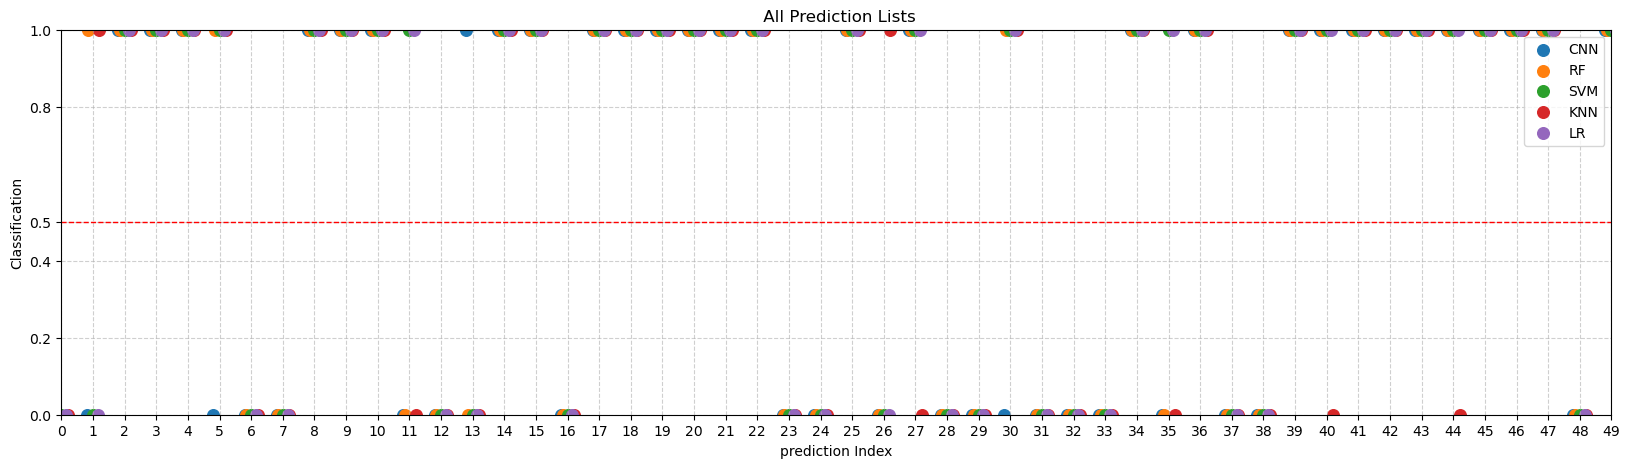

In [52]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


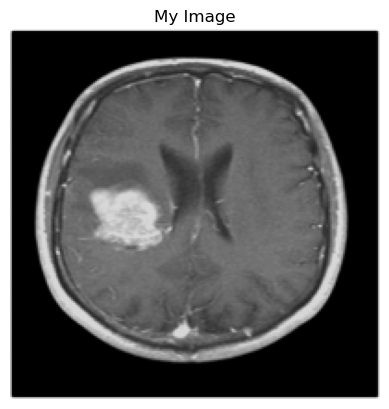

In [90]:
# Path to image
img_path = r"D:\My Final Work\external_pic\1.jpg"  # use raw string to avoid \n errors

# Read image
check_img = cv2.imread(img_path,1)
check_img=cv2.resize(check_img,(200,200))
# Show image
plt.imshow(check_img)
plt.axis('off')  # Hide axis numbers
plt.title("My Image")
plt.show()


In [91]:
outside_img =cv2.resize(check_img,(200,200))

In [92]:
outside_img.shape

(200, 200, 3)

In [75]:
cnnpred1=outside_img.reshape(1,200,200,3)
cnnpred=cnnpred1/255

In [93]:
cnnpred.shape

(1, 200, 200, 3)

In [94]:
cnnpred.ndim

4

In [95]:
p1=(cnn.predict(cnnpred)>0.5).astype('int').flatten()

1/1 [==============================] - 0s 49ms/step


In [96]:
print(p1)

[0]


# below is for 2D arrays

In [97]:
p_2D=outside_img.reshape(1, -1)
p_2D.shape

(1, 120000)

In [98]:
p_2D.ndim

2

In [99]:
p_2D=p_2D/255

In [100]:
p2=rf.predict(p_2D)

In [101]:
print(p2)

[1]


In [102]:
p3=svm.predict(p_2D)

In [103]:
print(p3)

[0]


In [104]:
p4=LR.predict(p_2D)

In [105]:
print(p4)

[0]


In [106]:
p5=knn.predict(p_2D)

In [107]:
print(p5)

[0]


In [108]:
if(p1+p2+p3+p4+p5 >= 3):
    print("Tumor")
else:
    print("No Tumor")


No Tumor
